In [4]:
import os

os.getcwd()

'C:\\Users\\sbora'

In [5]:
import pandas as pd

file_path = r"E:\Srikanth\Data_Analytics_Portfolio\healthcare-analytics-project\data\healthcare_claims.csv"

df = pd.read_csv(file_path)

df.head()

,Patient_ID,Age,Gender,State,Diagnosis,Provider,Admission_Date,Discharge_Date,Insurance_Type,Claim_Amount,Length_of_Stay,Claim_Status
0,P10333,74,Male,Pennsylvania,Asthma,Harrisburg General Hospital,2025-01-01,2025-01-06,Medicaid,6113.34,5,Paid
1,P10432,32,Female,Pennsylvania,COPD,Pinecrest Medical,2025-01-01,2025-01-02,Commercial,8639.97,1,Paid
2,P10606,37,Male,New Jersey,Cancer,Harrisburg General Hospital,2025-01-01,2025-01-10,Commercial,17528.79,9,Paid
3,P10641,56,Male,Pennsylvania,Heart Disease,Riverside Health,2025-01-01,2025-01-02,Commercial,9309.83,1,Pending
4,P11025,23,Female,New York,Kidney Disease,Community Care Hospital,2025-01-01,2025-01-08,Commercial,10117.34,7,Paid


In [6]:
df.shape

(5000, 12)

In [7]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'State',
 'Diagnosis',
 'Provider',
 'Admission_Date',
 'Discharge_Date',
 'Insurance_Type',
 'Claim_Amount',
 'Length_of_Stay',
 'Claim_Status']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient_ID      5000 non-null   object 
 1   Age             5000 non-null   int64  
 2   Gender          5000 non-null   object 
 3   State           5000 non-null   object 
 4   Diagnosis       5000 non-null   object 
 5   Provider        5000 non-null   object 
 6   Admission_Date  5000 non-null   object 
 7   Discharge_Date  5000 non-null   object 
 8   Insurance_Type  5000 non-null   object 
 9   Claim_Amount    5000 non-null   float64
 10  Length_of_Stay  5000 non-null   int64  
 11  Claim_Status    5000 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 468.9+ KB


In [9]:
df.isnull().sum()

Patient_ID        0
Age               0
Gender            0
State             0
Diagnosis         0
Provider          0
Admission_Date    0
Discharge_Date    0
Insurance_Type    0
Claim_Amount      0
Length_of_Stay    0
Claim_Status      0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Patient_ID      5000 non-null   object        
 1   Age             5000 non-null   int64         
 2   Gender          5000 non-null   object        
 3   State           5000 non-null   object        
 4   Diagnosis       5000 non-null   object        
 5   Provider        5000 non-null   object        
 6   Admission_Date  5000 non-null   datetime64[ns]
 7   Discharge_Date  5000 non-null   datetime64[ns]
 8   Insurance_Type  5000 non-null   object        
 9   Claim_Amount    5000 non-null   float64       
 10  Length_of_Stay  5000 non-null   int64         
 11  Claim_Status    5000 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(7)
memory usage: 468.9+ KB


In [12]:
df[['Admission_Date', 'Discharge_Date']].head()

,Admission_Date,Discharge_Date
0,2025-01-01,2025-01-06
1,2025-01-01,2025-01-02
2,2025-01-01,2025-01-10
3,2025-01-01,2025-01-02
4,2025-01-01,2025-01-08


In [13]:
summary = {
    "Total Claims": len(df),
    "Total Claim Amount": df["Claim_Amount"].sum(),
    "Average Claim Amount": df["Claim_Amount"].mean(),
    "Average Length of Stay": df["Length_of_Stay"].mean(),
    "Average Patient Age": df["Age"].mean()
}

summary

{'Total Claims': 5000,
 'Total Claim Amount': 41292040.85,
 'Average Claim Amount': 8258.40817,
 'Average Length of Stay': 4.6734,
 'Average Patient Age': 51.3748}

In [14]:
print(f"Total Claims: {len(df):,}")
print(f"Total Claim Amount: ${df['Claim_Amount'].sum():,.2f}")
print(f"Average Claim Amount: ${df['Claim_Amount'].mean():,.2f}")
print(f"Average Length of Stay: {df['Length_of_Stay'].mean():.1f} days")
print(f"Average Patient Age: {df['Age'].mean():.1f} years")

Total Claims: 5,000
Total Claim Amount: $41,292,040.85
Average Claim Amount: $8,258.41
Average Length of Stay: 4.7 days
Average Patient Age: 51.4 years


In [15]:
claim_status = df['Claim_Status'].value_counts()

claim_status

Paid       3907
Pending     711
Denied      382
Name: Claim_Status, dtype: int64

In [16]:
claim_status_pct = df['Claim_Status'].value_counts(normalize=True) * 100

claim_status_pct.round(2)

Paid       78.14
Pending    14.22
Denied      7.64
Name: Claim_Status, dtype: float64

In [17]:
df.groupby('Claim_Status')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).round(2)

,count,sum,mean
Claim_Status,,,
Denied,382,3218665.54,8425.83
Paid,3907,32094230.92,8214.55
Pending,711,5979144.39,8409.49


In [18]:
diagnosis_counts = df['Diagnosis'].value_counts()

diagnosis_counts

Hypertension        524
Pneumonia           518
Cancer              515
High Cholesterol    511
Diabetes            502
Heart Disease       497
Kidney Disease      494
Arthritis           494
Asthma              491
COPD                454
Name: Diagnosis, dtype: int64

In [19]:
diagnosis_analysis = df.groupby('Diagnosis')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

diagnosis_analysis.round(2)

,count,sum,mean
Diagnosis,,,
Cancer,515,8958561.12,17395.26
Heart Disease,497,5695864.89,11460.49
Kidney Disease,494,5029743.79,10181.67
Pneumonia,518,4415048.39,8523.26
COPD,454,4110212.62,9053.33
Diabetes,502,3101606.38,6178.50
Hypertension,524,2855921.40,5450.23
Arthritis,494,2441935.90,4943.19
High Cholesterol,511,2366929.85,4631.96


In [20]:
diagnosis_status = pd.crosstab(
    df['Diagnosis'],
    df['Claim_Status']
)

diagnosis_status

Claim_Status,Denied,Paid,Pending
Diagnosis,,,
Arthritis,40,405,49
Asthma,46,369,76
COPD,26,369,59
Cancer,43,387,85
Diabetes,38,397,67
Heart Disease,40,392,65
High Cholesterol,41,393,77
Hypertension,33,410,81
Kidney Disease,36,382,76


In [21]:
diagnosis_status_pct = pd.crosstab(
    df['Diagnosis'],
    df['Claim_Status'],
    normalize='index'
) * 100

diagnosis_status_pct.round(2)

Claim_Status,Denied,Paid,Pending
Diagnosis,,,
Arthritis,8.10,81.98,9.92
Asthma,9.37,75.15,15.48
COPD,5.73,81.28,13.00
Cancer,8.35,75.15,16.50
Diabetes,7.57,79.08,13.35
Heart Disease,8.05,78.87,13.08
High Cholesterol,8.02,76.91,15.07
Hypertension,6.30,78.24,15.46
Kidney Disease,7.29,77.33,15.38


In [22]:
df['Insurance_Type'].value_counts()
insurance_analysis = df.groupby('Insurance_Type')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

insurance_analysis.round(2)
insurance_status = pd.crosstab(
    df['Insurance_Type'],
    df['Claim_Status'],
    normalize='index'
) * 100

insurance_status.round(2)

Claim_Status,Denied,Paid,Pending
Insurance_Type,,,
Commercial,7.75,77.98,14.27
Medicaid,7.50,78.28,14.22
Medicare,7.71,77.87,14.42
Self-Pay,6.94,80.41,12.65


In [23]:
df['Insurance_Type'].value_counts()


Commercial    2180
Medicare      1401
Medicaid      1174
Self-Pay       245
Name: Insurance_Type, dtype: int64

In [24]:
insurance_analysis = df.groupby('Insurance_Type')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

insurance_analysis.round(2)

,count,sum,mean
Insurance_Type,,,
Commercial,2180,18113069.49,8308.75
Medicare,1401,11509902.48,8215.49
Medicaid,1174,9752838.83,8307.36
Self-Pay,245,1916230.05,7821.35


In [25]:
df['Provider'].nunique()

10

In [26]:
df['Provider'].value_counts()

Harrisburg General Hospital    521
Allegheny Health Center        517
Pinecrest Medical              516
Central PA Medical             516
Penn Valley Hospital           509
Community Care Hospital        506
Riverside Health               497
Keystone Medical Center        483
Summit Health System           477
Valley Care Hospital           458
Name: Provider, dtype: int64

In [27]:
provider_analysis = df.groupby('Provider')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

provider_analysis.round(2)

,count,sum,mean
Provider,,,
Pinecrest Medical,516,4419325.50,8564.58
Harrisburg General Hospital,521,4414011.54,8472.19
Community Care Hospital,506,4203755.21,8307.82
Allegheny Health Center,517,4185316.39,8095.39
Penn Valley Hospital,509,4148981.07,8151.24
Central PA Medical,516,4143905.84,8030.83
Keystone Medical Center,483,4095979.56,8480.29
Riverside Health,497,4069027.75,8187.18
Summit Health System,477,3851417.40,8074.25


In [28]:
provider_status = pd.crosstab(
    df['Provider'],
    df['Claim_Status'],
    normalize='index'
) * 100

provider_status.round(2)

Claim_Status,Denied,Paid,Pending
Provider,,,
Allegheny Health Center,8.51,75.82,15.67
Central PA Medical,7.95,76.94,15.12
Community Care Hospital,6.13,76.88,17.00
Harrisburg General Hospital,6.72,79.08,14.20
Keystone Medical Center,8.70,78.88,12.42
Penn Valley Hospital,7.86,79.37,12.77
Pinecrest Medical,8.33,75.97,15.70
Riverside Health,6.04,78.87,15.09
Summit Health System,7.76,80.50,11.74


In [29]:
df['State'].nunique()

7

In [30]:
df['State'].value_counts()

Pennsylvania    2120
New Jersey       690
New York         594
Virginia         522
Maryland         423
Ohio             371
Delaware         280
Name: State, dtype: int64

In [31]:
state_analysis = df.groupby('State')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

state_analysis.round(2)

,count,sum,mean
State,,,
Pennsylvania,2120,17548377.26,8277.54
New Jersey,690,5604885.93,8123.02
New York,594,5068524.81,8532.87
Virginia,522,4237924.40,8118.63
Maryland,423,3366571.34,7958.80
Ohio,371,3039685.90,8193.22
Delaware,280,2426071.21,8664.54


In [32]:
state_status = pd.crosstab(
    df['State'],
    df['Claim_Status'],
    normalize='index'
) * 100

state_status.round(2)

Claim_Status,Denied,Paid,Pending
State,,,
Delaware,7.50,81.07,11.43
Maryland,9.69,76.36,13.95
New Jersey,8.26,78.55,13.19
New York,6.73,79.29,13.97
Ohio,7.82,77.90,14.29
Pennsylvania,7.31,77.83,14.86
Virginia,7.47,77.59,14.94


In [33]:
df['Age'].describe()

count    5000.000000
mean       51.374800
std        19.640058
min        18.000000
25%        34.000000
50%        51.000000
75%        68.000000
max        85.000000
Name: Age, dtype: float64

In [34]:
df['Gender'].value_counts()

Female    2559
Male      2441
Name: Gender, dtype: int64

In [35]:
gender_analysis = df.groupby('Gender')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

gender_analysis.round(2)

,count,sum,mean
Gender,,,
Female,2559,21453206.09,8383.43
Male,2441,19838834.76,8127.34


In [36]:
bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df['Age_Group'].value_counts().sort_index()

0-18       69
19-35    1270
36-50    1112
51-65    1091
66+      1458
Name: Age_Group, dtype: int64

In [41]:
df['Length_of_Stay'].describe()

count    5000.000000
mean        4.673400
std         3.166376
min         1.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        14.000000
Name: Length_of_Stay, dtype: float64

In [42]:
los_analysis = df.groupby('Length_of_Stay')['Claim_Amount'].agg(
    ['count', 'sum', 'mean']
).sort_index()

los_analysis.round(2)

,count,sum,mean
Length_of_Stay,,,
1,729,4365147.58,5987.86
2,780,5158547.87,6613.52
3,738,5300804.81,7182.66
4,622,4957701.62,7970.58
5,497,4135661.65,8321.25
6,381,3484380.34,9145.36
7,324,3088556.04,9532.58
8,247,2535212.63,10264.02
9,187,2023720.33,10822.03


In [43]:
df[['Length_of_Stay', 'Claim_Amount']].corr()

,Length_of_Stay,Claim_Amount
Length_of_Stay,1.000000,0.437982
Claim_Amount,0.437982,1.000000


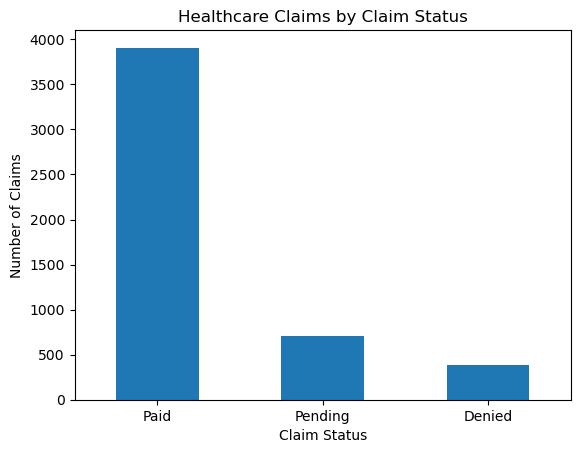

In [44]:
import matplotlib.pyplot as plt

claim_status = df['Claim_Status'].value_counts()

claim_status.plot(kind='bar')

plt.title('Healthcare Claims by Claim Status')
plt.xlabel('Claim Status')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.show()

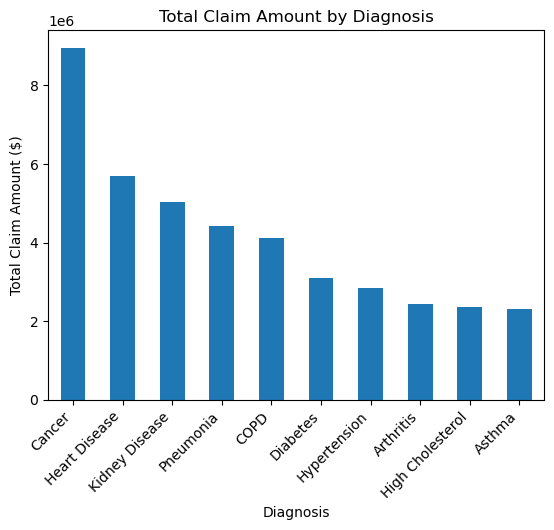

In [45]:
diagnosis_cost = df.groupby('Diagnosis')['Claim_Amount'].sum().sort_values(ascending=False)

diagnosis_cost.plot(kind='bar')

plt.title('Total Claim Amount by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Total Claim Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

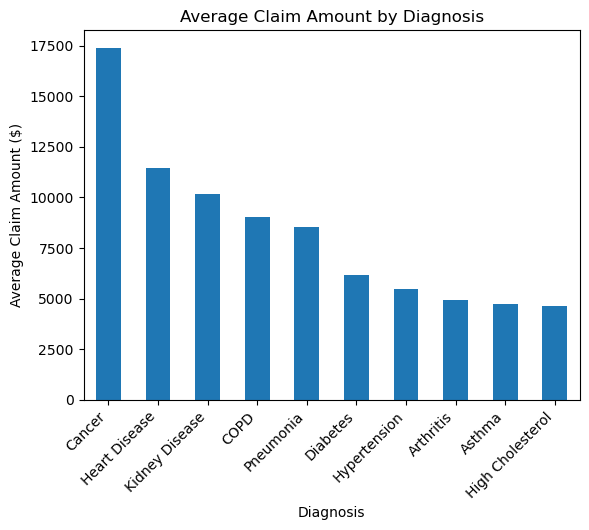

In [46]:
diagnosis_avg = df.groupby('Diagnosis')['Claim_Amount'].mean().sort_values(ascending=False)

diagnosis_avg.plot(kind='bar')

plt.title('Average Claim Amount by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Average Claim Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

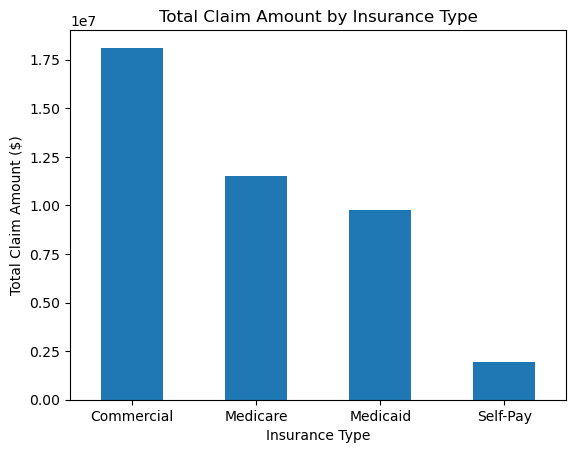

In [47]:
insurance_cost = df.groupby('Insurance_Type')['Claim_Amount'].sum().sort_values(ascending=False)

insurance_cost.plot(kind='bar')

plt.title('Total Claim Amount by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Total Claim Amount ($)')
plt.xticks(rotation=0)
plt.show()

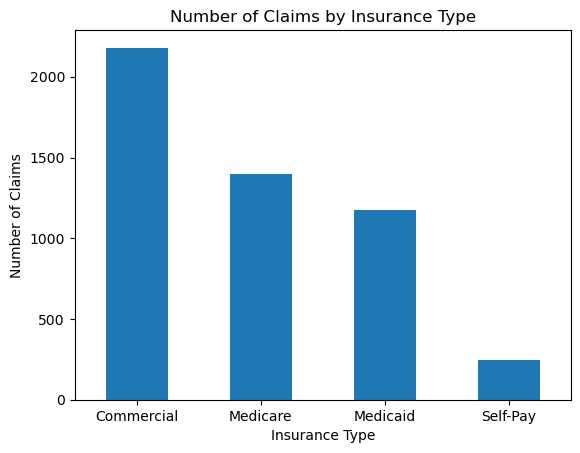

In [48]:
insurance_count = df['Insurance_Type'].value_counts()

insurance_count.plot(kind='bar')

plt.title('Number of Claims by Insurance Type')
plt.xlabel('Insurance Type')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.show()

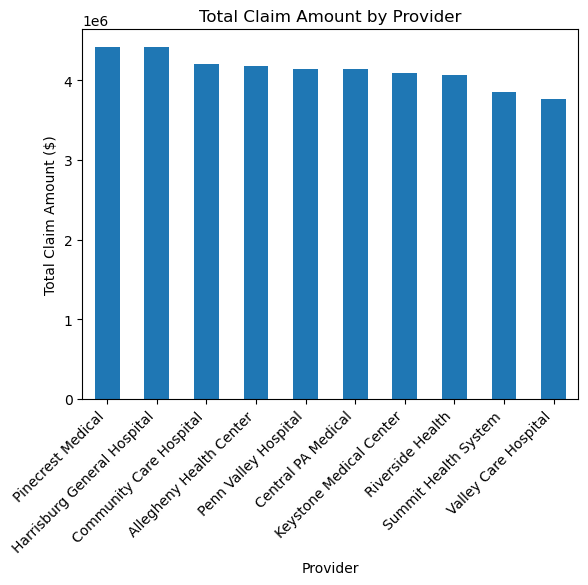

In [49]:
provider_cost = df.groupby('Provider')['Claim_Amount'].sum().sort_values(ascending=False)

provider_cost.plot(kind='bar')

plt.title('Total Claim Amount by Provider')
plt.xlabel('Provider')
plt.ylabel('Total Claim Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

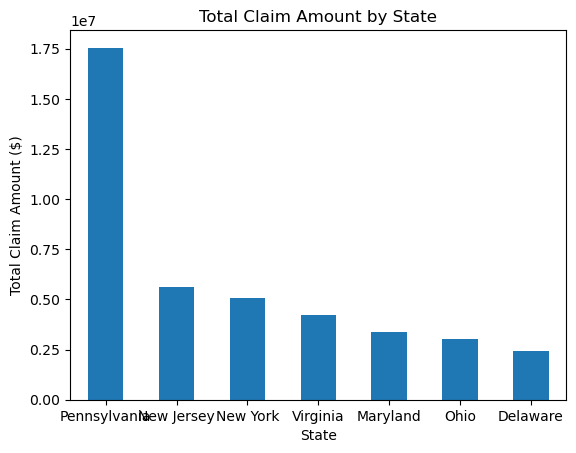

In [50]:
state_cost = df.groupby('State')['Claim_Amount'].sum().sort_values(ascending=False)

state_cost.plot(kind='bar')

plt.title('Total Claim Amount by State')
plt.xlabel('State')
plt.ylabel('Total Claim Amount ($)')
plt.xticks(rotation=0)
plt.show()

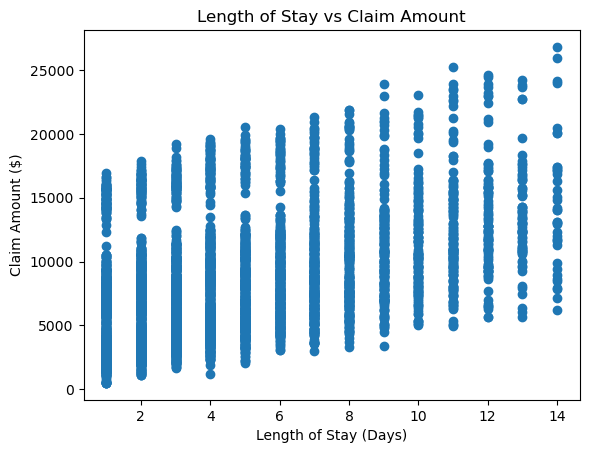

In [51]:
plt.scatter(df['Length_of_Stay'], df['Claim_Amount'])

plt.title('Length of Stay vs Claim Amount')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Claim Amount ($)')
plt.show()

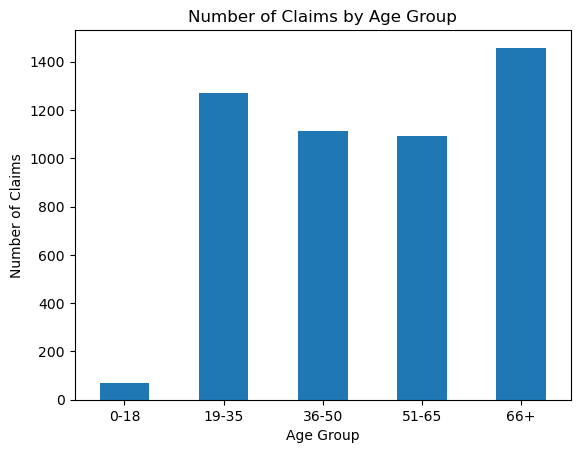

In [52]:
age_group_count = df['Age_Group'].value_counts().sort_index()

age_group_count.plot(kind='bar')

plt.title('Number of Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.show()

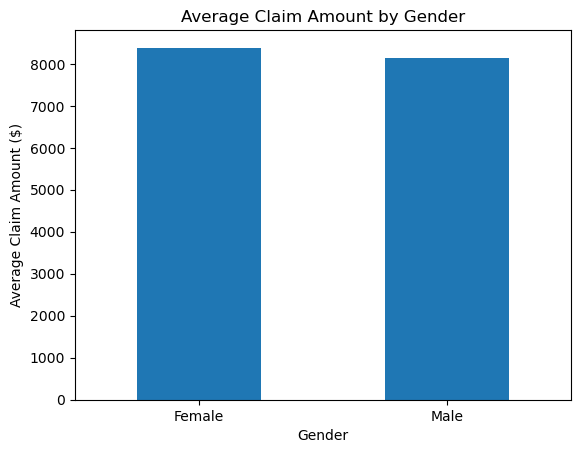

In [53]:
gender_cost = df.groupby('Gender')['Claim_Amount'].mean()

gender_cost.plot(kind='bar')

plt.title('Average Claim Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Claim Amount ($)')
plt.xticks(rotation=0)
plt.show()

In [54]:
df['Admission_Month'] = df['Admission_Date'].dt.to_period('M')

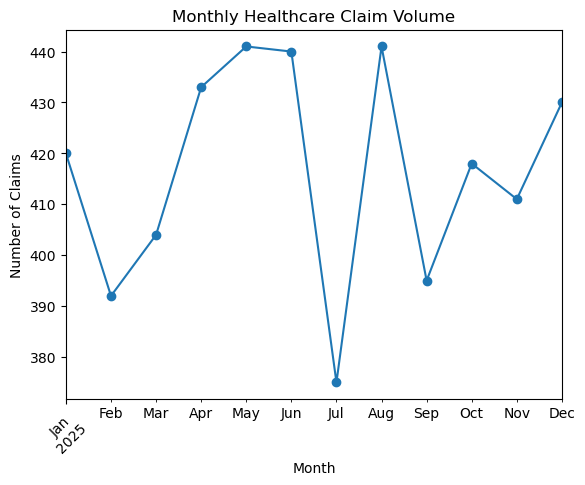

In [55]:
monthly_claims = df.groupby('Admission_Month').size()

monthly_claims.plot(kind='line', marker='o')

plt.title('Monthly Healthcare Claim Volume')
plt.xlabel('Month')
plt.ylabel('Number of Claims')
plt.xticks(rotation=45)
plt.show()

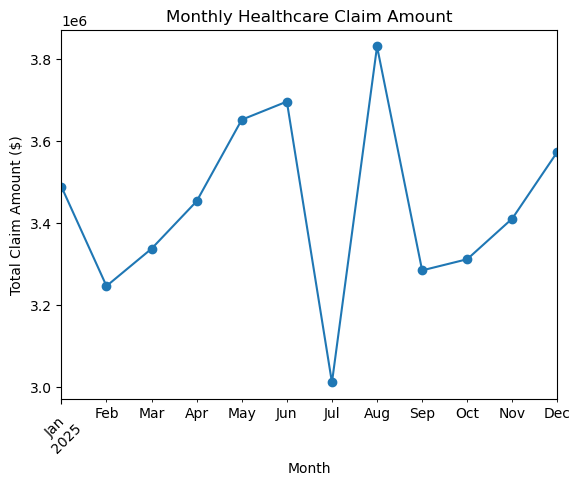

In [56]:
monthly_cost = df.groupby('Admission_Month')['Claim_Amount'].sum()

monthly_cost.plot(kind='line', marker='o')

plt.title('Monthly Healthcare Claim Amount')
plt.xlabel('Month')
plt.ylabel('Total Claim Amount ($)')
plt.xticks(rotation=45)
plt.show()

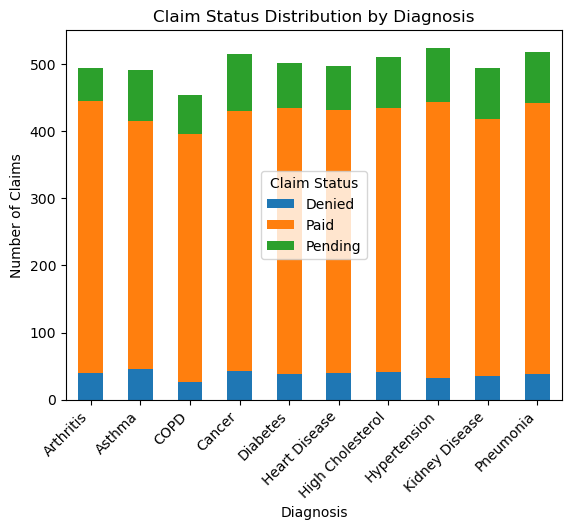

In [57]:
diagnosis_status = pd.crosstab(
    df['Diagnosis'],
    df['Claim_Status']
)

diagnosis_status.plot(kind='bar', stacked=True)

plt.title('Claim Status Distribution by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Claims')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Status')
plt.show()

In [58]:
output_file = r"E:\Srikanth\Data_Analytics_Portfolio\healthcare-analytics-project\data\healthcare_claims_cleaned.csv"

df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
